# Collider bias and the birth weight paradox

This notebook builds a synthetic version of the **birth weight paradox**: maternal smoking lowers birth weight and raises infant mortality overall, yet among low-birth-weight babies smokers can appear to have *lower* mortality.

The point is not to model real clinical data. It is to show how the paradox can arise mechanically when we condition on a **collider**.

## Causal story

We simulate three causes of birth weight and mortality:

- `smoking`: mildly lowers birth weight and directly increases mortality risk.
- `frailty`: an unobserved/common-risk factor that strongly lowers birth weight and strongly increases mortality risk.
- `gestational_age`: shorter gestation lowers birth weight and increases mortality risk.

Birth weight is a **collider** because both smoking and frailty point into it:

```text
smoking  -----> birth_weight <----- frailty
   |                                  |
   v                                  v
mortality <----------------------------
```

If we restrict analysis to low-birth-weight babies, observing `smoking` makes severe unobserved frailty less likely, because smoking itself already helps explain low birth weight. Conversely, low-birth-weight babies of non-smokers are enriched for the stronger hidden causes of low birth weight. That induced association can reverse the within-stratum comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260808)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

n = 250_000

# Maternal smoking is mildly more common when socioeconomic risk is high.
socioeconomic_risk = rng.normal(0, 1, n)
p_smoking = sigmoid(-1.25 + 0.65 * socioeconomic_risk)
smoking = rng.binomial(1, p_smoking)

# A latent risk factor: congenital/placental/neonatal frailty, unobserved by the analyst.
frailty = rng.normal(0, 1, n)

# Gestational age in completed weeks. Frailty and smoking slightly increase prematurity.
gestational_age = (
    39.2
    - 0.35 * smoking
    - 1.00 * frailty
    - 0.25 * socioeconomic_risk
    + rng.normal(0, 1.25, n)
)
gestational_age = np.clip(gestational_age, 24, 42)

# Birth weight in grams. Smoking lowers weight, but frailty and prematurity can lower it much more.
birth_weight = (
    3400
    - 230 * smoking
    - 420 * frailty
    + 145 * (gestational_age - 39)
    - 55 * socioeconomic_risk
    + rng.normal(0, 310, n)
)
birth_weight = np.clip(birth_weight, 500, 5200)

low_birth_weight = birth_weight < 2500

# Mortality probability. Smoking is harmful, but frailty/low weight/prematurity dominate the risk profile.
logit_mortality = (
    -8.35
    + 0.35 * smoking
    + 1.75 * frailty
    + 0.95 * low_birth_weight
    + 0.16 * (37 - gestational_age)
)
mortality_probability = sigmoid(logit_mortality)
mortality = rng.binomial(1, mortality_probability)

df = pd.DataFrame(
    {
        "smoking": smoking,
        "frailty": frailty,
        "gestational_age": gestational_age,
        "birth_weight": birth_weight,
        "low_birth_weight": low_birth_weight,
        "mortality_probability": mortality_probability,
        "mortality": mortality,
    }
)

df.head()

,smoking,frailty,gestational_age,birth_weight,low_birth_weight,mortality_probability,mortality
0,0,1.082788,36.726038,2736.667415,False,0.001640,0
1,0,0.363507,37.699456,2825.748122,False,0.000399,0
2,0,-0.061272,38.063209,3429.621850,False,0.000179,0
3,1,0.944984,36.593713,2573.462325,False,0.001868,0
4,0,0.507218,39.655181,3591.635167,False,0.000375,0


In [3]:
summary = df.assign(smoking=df["smoking"].map({0: "non-smoker", 1: "smoker"})).groupby("smoking").agg(
    babies=("mortality", "size"),
    mean_birth_weight=("birth_weight", "mean"),
    low_birth_weight_rate=("low_birth_weight", "mean"),
    mortality_rate=("mortality", "mean"),
    mean_frailty=("frailty", "mean"),
)
summary.style.format(
    {
        "mean_birth_weight": "{:.0f} g",
        "low_birth_weight_rate": "{:.2%}",
        "mortality_rate": "{:.3%}",
        "mean_frailty": "{:.2f}",
    }
)

,babies,mean_birth_weight,low_birth_weight_rate,mortality_rate,mean_frailty
smoking,,,,,
non-smoker,189698,3437 g,8.07%,0.174%,0.00
smoker,60302,3110 g,18.14%,0.298%,-0.01


Overall, smoking does what we built into the data-generating process: smokers have lower average birth weight, more low-birth-weight babies, and higher mortality.

In [4]:
by_lbw = (
    df.assign(
        smoking=df["smoking"].map({0: "non-smoker", 1: "smoker"}),
        birth_weight_group=np.where(df["low_birth_weight"], "low birth weight", "not low birth weight"),
    )
    .groupby(["birth_weight_group", "smoking"])
    .agg(
        babies=("mortality", "size"),
        mortality_rate=("mortality", "mean"),
        mean_birth_weight=("birth_weight", "mean"),
        mean_frailty=("frailty", "mean"),
    )
)
by_lbw.style.format(
    {
        "mortality_rate": "{:.3%}",
        "mean_birth_weight": "{:.0f} g",
        "mean_frailty": "{:.2f}",
    }
)

Inside the low-birth-weight stratum, the comparison can flip: low-birth-weight babies of smokers may look healthier than low-birth-weight babies of non-smokers. The key diagnostic is `mean_frailty`: conditioning on low birth weight induces a negative association between smoking and the hidden severe-risk cause.

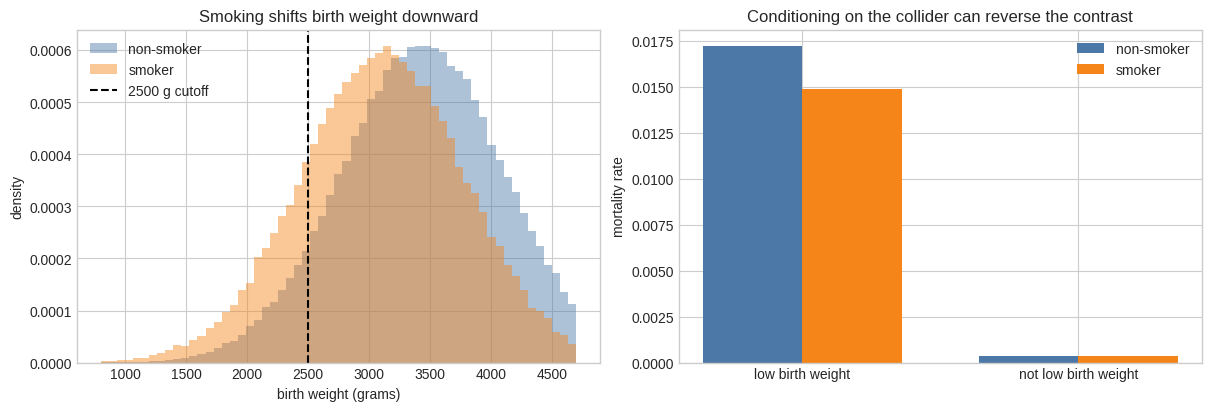

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Birth-weight distributions by smoking status.
bins = np.linspace(800, 4700, 60)
for value, label, color in [(0, "non-smoker", "#4C78A8"), (1, "smoker", "#F58518")]:
    axes[0].hist(df.loc[df.smoking == value, "birth_weight"], bins=bins, density=True, alpha=0.45, label=label, color=color)
axes[0].axvline(2500, color="black", linestyle="--", linewidth=1.5, label="2500 g cutoff")
axes[0].set_title("Smoking shifts birth weight downward")
axes[0].set_xlabel("birth weight (grams)")
axes[0].set_ylabel("density")
axes[0].legend()

# Mortality by smoking and low-birth-weight strata.
plot_data = by_lbw.reset_index()
order = ["low birth weight", "not low birth weight"]
x = np.arange(len(order))
width = 0.36
for i, label in enumerate(["non-smoker", "smoker"]):
    vals = plot_data.set_index(["birth_weight_group", "smoking"]).loc[(order, label), "mortality_rate"].to_numpy()
    axes[1].bar(x + (i - 0.5) * width, vals, width, label=label, color=["#4C78A8", "#F58518"][i])
axes[1].set_xticks(x, order)
axes[1].set_title("Conditioning on the collider can reverse the contrast")
axes[1].set_ylabel("mortality rate")
axes[1].legend()

plt.show()

In [6]:
def risk_difference(data):
    rates = data.groupby("smoking")["mortality"].mean()
    return rates.loc[1] - rates.loc[0]

overall_rd = risk_difference(df)
lbw_rd = risk_difference(df[df.low_birth_weight])
normal_bw_rd = risk_difference(df[~df.low_birth_weight])

pd.Series(
    {
        "smoker minus non-smoker mortality risk difference, all babies": overall_rd,
        "same contrast, only low-birth-weight babies": lbw_rd,
        "same contrast, only not-low-birth-weight babies": normal_bw_rd,
    }
).map(lambda x: f"{x:+.3%}")

,0
"smoker minus non-smoker mortality risk difference, all babies",+0.124%
"same contrast, only low-birth-weight babies",-0.234%
"same contrast, only not-low-birth-weight babies",-0.004%


## Why this is a bias, not a protective effect

The synthetic data-generating process gives smoking a harmful direct coefficient in the mortality equation. The apparent protective association among low-birth-weight babies is therefore known to be wrong. It appears because the analysis selected on a downstream common effect of smoking and frailty.

A useful rule of thumb: do not automatically stratify, match, or adjust for post-exposure variables. If a variable is caused by the exposure and also caused by hidden determinants of the outcome, conditioning on it can open a non-causal path and create collider bias.